# Week 2: Department Classification Model
## AI-Driven Citizen Grievance & Sentiment Analysis System

### Objective
#Build a machine learning model that predicts the responsible government department/agency from a citizen complaint.

### Example
#**Input:** "Pothole on road near my area"  
#**Output:** `DOT`

In [3]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [4]:
df = pd.read_csv("../data/final_cleaned_grievances.csv")
df.head()

,Complaint Type,Descriptor,Agency,Agency Name,text,clean_text
0,Street Condition,Pothole,DOT,Department of Transportation,Street Condition Pothole,street condition pothole
1,Noise - Commercial,Loud Music/Party,NYPD,New York City Police Department,Noise - Commercial Loud Music/Party,noise commercial loud musicparty
2,Noise - Residential,Loud Music/Party,NYPD,New York City Police Department,Noise - Residential Loud Music/Party,noise residential loud musicparty
3,Noise - Residential,Loud Music/Party,NYPD,New York City Police Department,Noise - Residential Loud Music/Party,noise residential loud musicparty
4,Illegal Parking,Commercial Overnight Parking,NYPD,New York City Police Department,Illegal Parking Commercial Overnight Parking,illegal parking commercial overnight parking


In [5]:
print("Dataset shape:", df.shape)

Dataset shape: (49980, 6)


In [6]:
print(df.columns)

Index(['Complaint Type', 'Descriptor', 'Agency', 'Agency Name', 'text',
       'clean_text'],
      dtype='object')


In [7]:
print(df.isnull().sum())

Complaint Type       0
Descriptor        1141
Agency               0
Agency Name          0
text                 0
clean_text           0
dtype: int64


In [8]:
print(df['Agency'].value_counts())

Agency
NYPD     22207
HPD      10079
DOT       4990
DEP       3812
DSNY      2353
DOB       2134
DOHMH     1181
DPR       1107
TLC        995
DHS        659
DCA        250
EDC        213
Name: count, dtype: int64


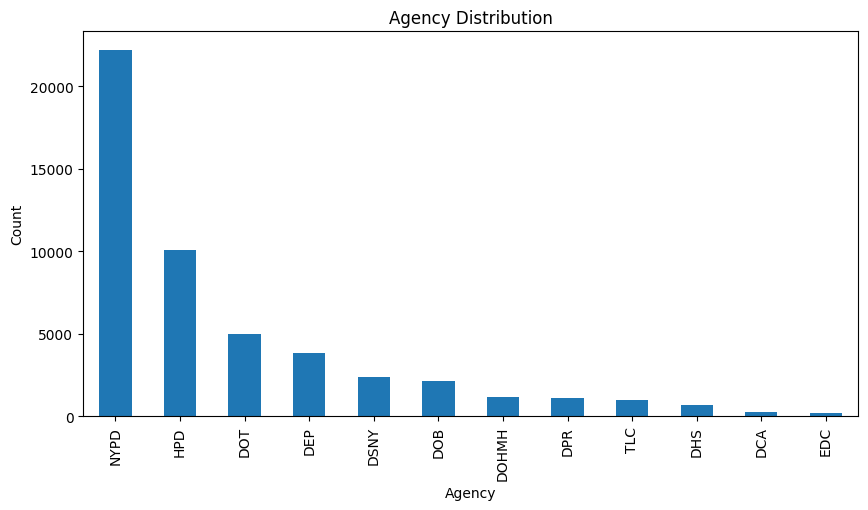

In [9]:
#Plot Agency Distribution
df['Agency'].value_counts().plot(kind='bar', figsize=(10,5))
plt.title("Agency Distribution")
plt.xlabel("Agency")
plt.ylabel("Count")
plt.show()

In [10]:
#Define Features and Labels
X = df['clean_text']
y = df['Agency']

print("Number of samples:", len(X))

Number of samples: 49980


In [11]:
#Convert Text to TF-IDF Features
vectorizer = TfidfVectorizer(max_features=5000)

X_tfidf = vectorizer.fit_transform(X)

print("TF-IDF shape:", X_tfidf.shape)

TF-IDF shape: (49980, 840)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 39984
Testing samples: 9996


In [13]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [14]:
y_pred = model.predict(X_test)

In [15]:
#Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9996998799519808


In [16]:
#Classification Report
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

         DCA       1.00      1.00      1.00        50
         DEP       1.00      1.00      1.00       762
         DHS       1.00      1.00      1.00       132
         DOB       1.00      1.00      1.00       427
       DOHMH       1.00      0.99      0.99       236
         DOT       1.00      1.00      1.00       998
         DPR       1.00      1.00      1.00       221
        DSNY       1.00      1.00      1.00       471
         EDC       1.00      1.00      1.00        43
         HPD       1.00      1.00      1.00      2016
        NYPD       1.00      1.00      1.00      4441
         TLC       1.00      1.00      1.00       199

    accuracy                           1.00      9996
   macro avg       1.00      1.00      1.00      9996
weighted avg       1.00      1.00      1.00      9996



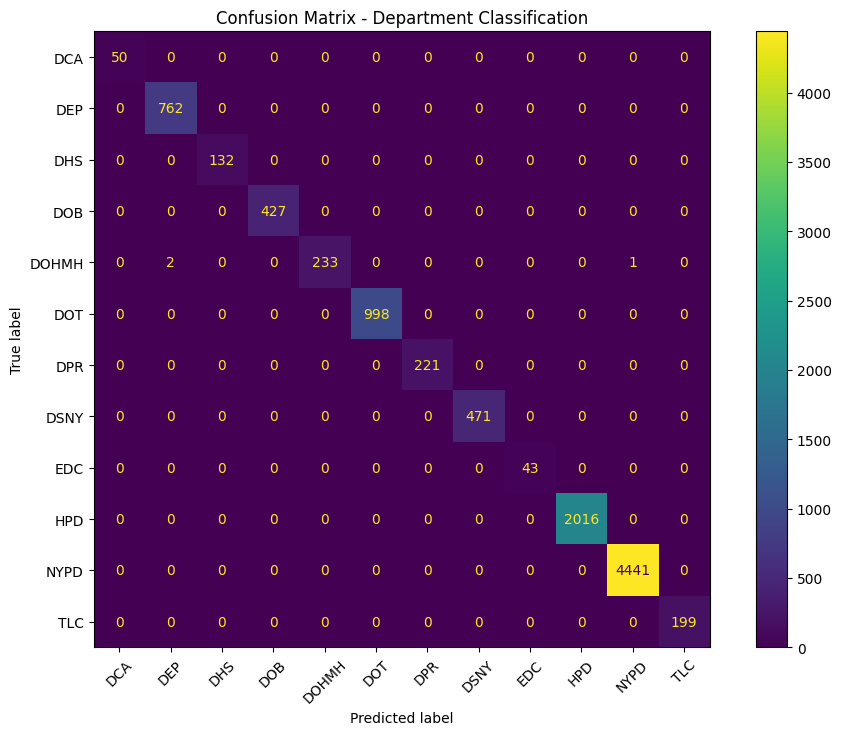

In [17]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
fig, ax = plt.subplots(figsize=(12, 8))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix - Department Classification")
plt.show()

In [18]:
#Test Model on Custom Complaints
sample_complaints = [
    "There is a pothole on the road",
    "Loud music coming from a nearby house at night",
    "Garbage has not been collected for two days",
    "Water leakage in my building",
    "Street light is not working",
    "i see a massive pothole on the street"
]

sample_vectors = vectorizer.transform(sample_complaints)
predictions = model.predict(sample_vectors)

for complaint, pred in zip(sample_complaints, predictions):
    print(f"Complaint: {complaint}")
    print(f"Predicted Agency: {pred}")
    print("-" * 50)

Complaint: There is a pothole on the road
Predicted Agency: DOT
--------------------------------------------------
Complaint: Loud music coming from a nearby house at night
Predicted Agency: NYPD
--------------------------------------------------
Complaint: Garbage has not been collected for two days
Predicted Agency: NYPD
--------------------------------------------------
Complaint: Water leakage in my building
Predicted Agency: HPD
--------------------------------------------------
Complaint: Street light is not working
Predicted Agency: DOT
--------------------------------------------------
Complaint: i see a massive pothole on the street
Predicted Agency: DOT
--------------------------------------------------


In [19]:
#Show Top Important Words for Each Agency (it is optional but it is good for accurate prediction)
feature_names = vectorizer.get_feature_names_out()

for i, agency in enumerate(model.classes_):
    top10 = np.argsort(model.coef_[i])[-10:]
    print(f"\nTop words for agency {agency}:")
    print(", ".join(feature_names[top10]))


Top words for agency DCA:
contractor, company, dealer, used, truck, tow, retail, store, complaint, consumer

Top words for agency DEP:
hazardous, comment, nr, quality, air, lead, noise, sewer, water, system

Top words for agency DHS:
mosquito, gaming, dumbwaiter, dirt, aps, whp, debt, homeless, person, assistance

Top words for agency DOB:
illegal, device, team, work, electrical, boiler, general, elevator, buildinguse, constructionplumbing

Top words for agency DOHMH:
dust, sewage, animal, heat, pigeon, establishment, smoking, indoor, rodent, food

Top words for agency DOT:
traffic, ferry, highway, sign, sidewalk, meter, signal, broken, street, condition

Top words for agency DPR:
damaged, animal, rule, rootsewersidewalk, treebranches, overgrown, maintenance, facility, park, tree

Top words for agency DSNY:
vehicle, condition, conddumpoutdropoff, sanitation, enforcement, material, collection, missed, derelict, dirty

Top words for agency EDC:
tunnel, dumbwaiter, gaming, dirt, whp, gat

In [20]:
#Save the Model
joblib.dump(model, "../models/department_model.pkl")
joblib.dump(vectorizer, "../models/tfidf_vectorizer.pkl")

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


In [21]:
print("Week 2 Completed Successfully!")
print("Final Accuracy:", accuracy)
print("Saved files:")
print("1. ../models/department_model.pkl")
print("2. ../models/tfidf_vectorizer.pkl")

Week 2 Completed Successfully!
Final Accuracy: 0.9996998799519808
Saved files:
1. ../models/department_model.pkl
2. ../models/tfidf_vectorizer.pkl
